# Fase 6 — Backtesting e Diebold-Mariano

**Companion: Nielsen, cap. 11.** AIC e diagnóstico de resíduos avaliam o ajuste *dentro* da amostra. O que importa é a previsão *fora* da amostra:

1. **Walk-forward** (origem móvel, 1 passo à frente): re-treina a cada mês e prevê o seguinte.
2. Comparação contra baselines **naïve** (repete o último) e **sazonal-naïve** (repete 12 meses atrás).
3. **Diebold-Mariano**: a diferença de acurácia é estatisticamente significativa?

> Regra de ouro: um modelo só se justifica se bate os baselines ingênuos fora da amostra.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from series_eco.data import loaders
from series_eco.models import arima
from series_eco.eval import backtest

ipca = loaders.load_panel("2000-01-01")["ipca"]

def sarima_forecaster(train):
    return arima.fit_sarima(train, (2, 0, 1), (1, 0, 1, 12)).forecast(1).iloc[0]

forecasters = {
    "Naïve": backtest.naive,
    "Sazonal-naïve": backtest.seasonal_naive,
    "SARIMA": sarima_forecaster,
}

## 1. Walk-forward nos últimos 24 meses

Cada modelo é avaliado nas mesmas 24 origens, prevendo sempre o mês seguinte com base apenas no passado.

In [2]:
N_TEST = 24
metricas, previsoes = {}, {}
for nome, fc in forecasters.items():
    real, prev = backtest.walk_forward(ipca, fc, n_test=N_TEST)
    m = backtest.compute_metrics(real, prev)
    metricas[nome] = {"MAE": m.mae, "RMSE": m.rmse, "MAPE(%)": m.mape}
    previsoes[nome] = (real, prev)

tabela = pd.DataFrame(metricas).T.round(4)
tabela

,MAE,RMSE,MAPE(%)
Naïve,0.2804,0.3803,167.7842
Sazonal-naïve,0.2317,0.2741,127.3208
SARIMA,0.2207,0.3098,154.2520


## 2. Previsões vs. realizado

Ver as previsões sobrepostas ao IPCA real torna concreto onde cada modelo acerta e erra — especialmente nos meses de virada.

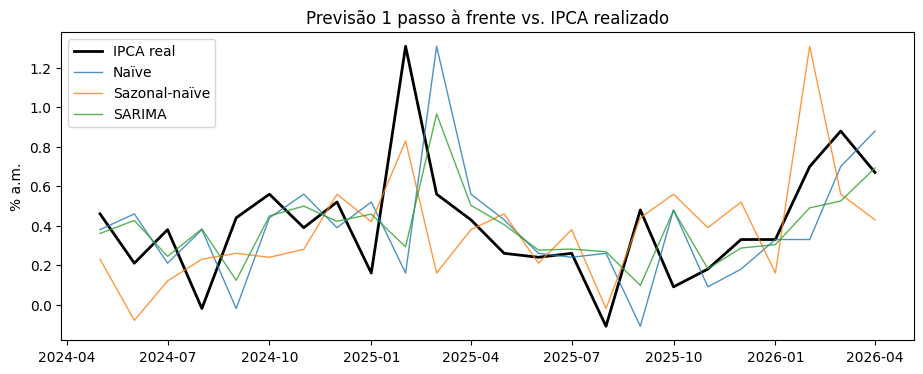

In [3]:
real, _ = previsoes["SARIMA"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(real.index, real, color="black", linewidth=2, label="IPCA real")
for nome, (_, prev) in previsoes.items():
    ax.plot(prev.index, prev, linewidth=1, alpha=0.8, label=nome)
ax.set_title("Previsão 1 passo à frente vs. IPCA realizado")
ax.set_ylabel("% a.m.")
ax.legend()
plt.show()

## 3. Comparação de RMSE e Diebold-Mariano

O gráfico de barras resume o erro; o teste de Diebold-Mariano (H0: mesma acurácia) diz se a diferença entre SARIMA e o melhor baseline é significativa.

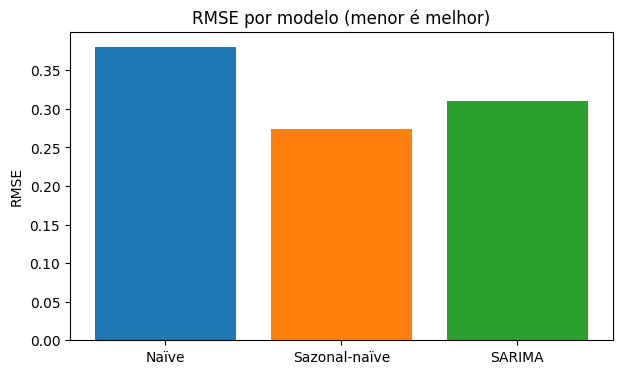

DM stat = 0.551  p = 0.5820
Resultado: empate  (model1=SARIMA, model2=Sazonal-naïve)


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tabela.index, tabela["RMSE"], color=["C0", "C1", "C2"])
ax.set_title("RMSE por modelo (menor é melhor)")
ax.set_ylabel("RMSE")
plt.show()

real, prev_sarima = previsoes["SARIMA"]
_, prev_snaive = previsoes["Sazonal-naïve"]
dm = backtest.diebold_mariano(real, prev_sarima, prev_snaive)
print(f"DM stat = {dm.statistic:.3f}  p = {dm.pvalue:.4f}")
print(f"Resultado: {dm.better}  (model1=SARIMA, model2=Sazonal-naïve)")

---
## Fechamento

Se o SARIMA **não** vence o sazonal-naïve de forma significativa, a lição é a do cap. 11 da Nielsen: ajuste bonito dentro da amostra (AIC baixo, resíduos brancos) **não garante** previsão melhor fora dela. A complexidade precisa pagar o próprio custo, medida por um teste formal — não pela elegância da técnica.

**Próxima fase:** Fase 7 traz um modelo de Machine Learning (gradient boosting) ao mesmo backtest, para um confronto justo.